# Hovmoller sections of dDLR/dlatitude — one figure per season

Latitude-time sections of the **meridional gradient of downwelling longwave**
along a narrow strip running north from the DOE ARM site at Utqiagvik, with
sea ice concentration contoured on top so the radiation field can be read
against the advancing ice edge.

One figure per season in the range set below, plus the climatology across all
of them. **The archive is read once.** `build_section` keeps the season axis
intact, so each per-season figure is a slice of the strip already in memory,
not another pass over the files -- which at roughly nine minutes per open is
the difference between one wait and eleven.

Everything here comes from `plot_latitude_time_hovmoller_DLR.py`; this
notebook holds no analysis code of its own.

### What the derivative panel is

The **time mean of the derivative, not the derivative of the time mean**.
`d/dlatitude` is evaluated at every individual time step, season and location
first, and only then averaged. The two differ whenever the meridional gradient
co-varies with the flow, which is precisely the freeze-up case these figures
are for.

Sign convention is native ERA5, **positive downward**. Positive values mean
DLR increases northward at that latitude and time.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import warnings
from pathlib import Path

import matplotlib.pyplot as plt

import plot_latitude_time_hovmoller_DLR as hov

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 110      # on-screen only; saved files use dpi=

SAVE_DIR = Path("figures/hovmoller_dlwd_dlat")

## Inputs

Everything that decides what gets loaded and plotted. Changing any of these
means re-running the load cell below; nothing else does.

`years` selects the seasons by the year each season **starts** in, so
`range(2015, 2026)` is 11 seasons, 2015/2016 through 2025/2026 — and 11
figures. Naming years explicitly overrides `min_season_coverage`, so a short
season is still drawn if you ask for it (with a warning) rather than silently
dropped.

In [2]:
REGION        = "barrow"
YEARS         = tuple(range(2015, 2026))   # season START years -> 11 seasons
SEASON_START  = (8, 1)                     # MM, DD
SEASON_END    = (3, 31)                     # MM, DD; wraps the new year

QUANTITY      = "dlwd_dlat"                # d(downwelling LW)/d(latitude)
ICE_LEVELS    = (0.05, 0.95)               # sea ice contours drawn on top

# The strip itself. Defaults follow the script: 3 cells about the ARM
# longitude, and the full latitude range of the downloaded region.
N_LON_CELLS   = 3
LAT_SOUTH     = None                       # None -> southern edge of the data
LAT_NORTH     = None                       # None -> northern edge

MIN_SEASON_COVERAGE = 0.6                  # only filters when YEARS is None
CONTOUR_STYLE = "contrast"                 # or "black"
DPI           = 350

## Load the data

The slow cell, and the only one that touches the archive.

In [3]:
A = hov.prepare(
    region=REGION,
    years=YEARS,
    season_start=SEASON_START,
    season_end=SEASON_END,
    quantity=QUANTITY,
    ice_levels=ICE_LEVELS,
    n_lon_cells=N_LON_CELLS,
    lat_south=LAT_SOUTH,
    lat_north=LAT_NORTH,
    min_season_coverage=MIN_SEASON_COVERAGE,
    contour_style=CONTOUR_STYLE,
    storage="local",
    dpi=DPI,
)

print(f"\nseasons to plot ({len(A.used)}): {A.used}")

Latitude-time sections of surface longwave
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Strip      : 70.000N to 80.000N, 3 cells about -156.611E
  Season     : 08-01 to 03-31  (wraps the new year)

  Seasons found (18), coverage of the 244-day window:
    1999/2000:  37.3%   (below --min-season-coverage)
    2000/2001:  99.6%
    2001/2002:  62.7%
    2011/2012: 100.0%
    2012/2013:  99.6%
    2013/2014:  99.6%
    2014/2015:  99.6%
    2015/2016: 100.0%
    2016/2017:  99.6%
    2017/2018:  95.1%
    2018/2019:  99.6%
    2019/2020: 100.0%
    2020/2021:  99.6%
    2021/2022:  99.6%
    2022/2023:  99.6%
    2023/2024: 100.0%
    2024/2025:  99.6%
    2025/2026:  99.6%

  Using 11 season(s): [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
  Land edge  : 71.25N (northernmost latitude with any land in the strip)

seasons to plot (11): [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


## Numeric report

Mean and range of the sectioned quantity over the kept seasons. Optional.

In [4]:
hov.print_report(A)

  d(downwelling LW)/d(latitude): mean=-1.54, range -23.39 to 31.50 [W m-2 per deg lat]


## One figure per season

`all_season_figures` draws every kept season in order and returns the list.
No reload -- each is a slice of the strip already in memory.

Each figure is titled with its own season, and saved as
`{region}_hovmoller_{quantity}_season{YYYY}.png`.

    figure -> figures/hovmoller_dlwd_dlat/barrow_hovmoller_dlwd_dlat_season2015.png
    figure -> figures/hovmoller_dlwd_dlat/barrow_hovmoller_dlwd_dlat_season2016.png
    figure -> figures/hovmoller_dlwd_dlat/barrow_hovmoller_dlwd_dlat_season2017.png
    figure -> figures/hovmoller_dlwd_dlat/barrow_hovmoller_dlwd_dlat_season2018.png
    figure -> figures/hovmoller_dlwd_dlat/barrow_hovmoller_dlwd_dlat_season2019.png
    figure -> figures/hovmoller_dlwd_dlat/barrow_hovmoller_dlwd_dlat_season2020.png
    figure -> figures/hovmoller_dlwd_dlat/barrow_hovmoller_dlwd_dlat_season2021.png
    figure -> figures/hovmoller_dlwd_dlat/barrow_hovmoller_dlwd_dlat_season2022.png
    figure -> figures/hovmoller_dlwd_dlat/barrow_hovmoller_dlwd_dlat_season2023.png
    figure -> figures/hovmoller_dlwd_dlat/barrow_hovmoller_dlwd_dlat_season2024.png
    figure -> figures/hovmoller_dlwd_dlat/barrow_hovmoller_dlwd_dlat_season2025.png
11 figures


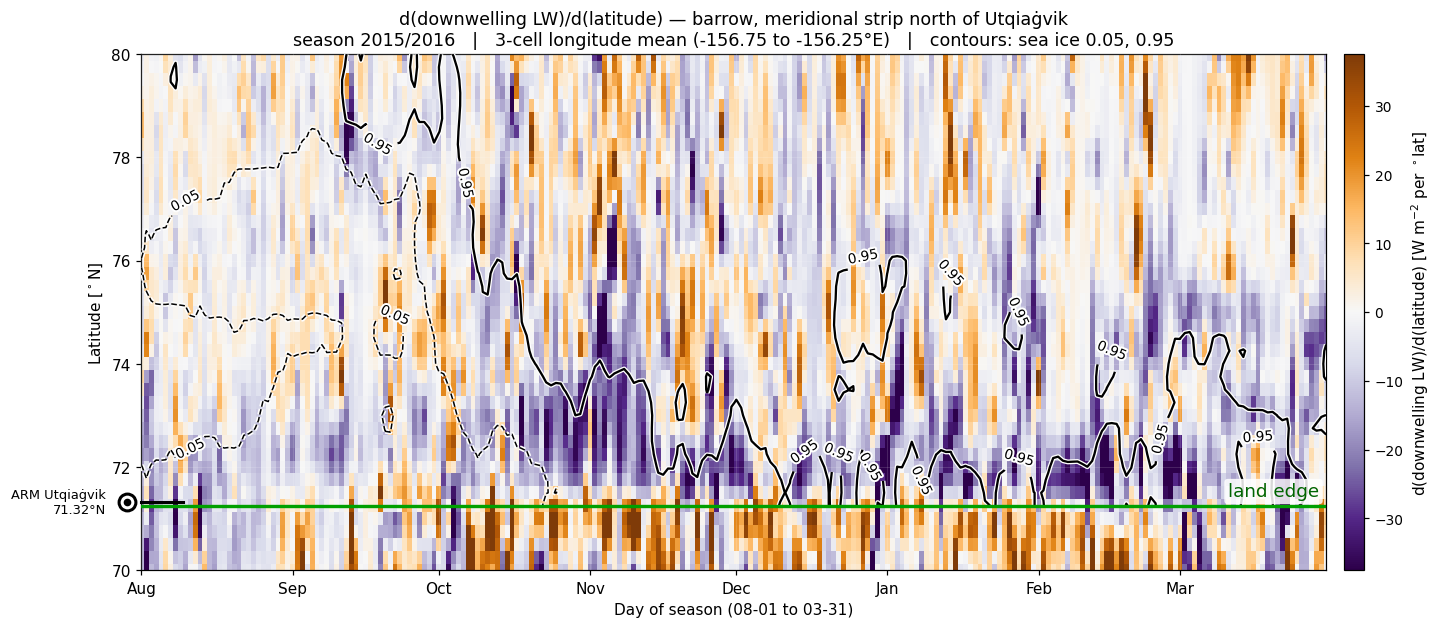

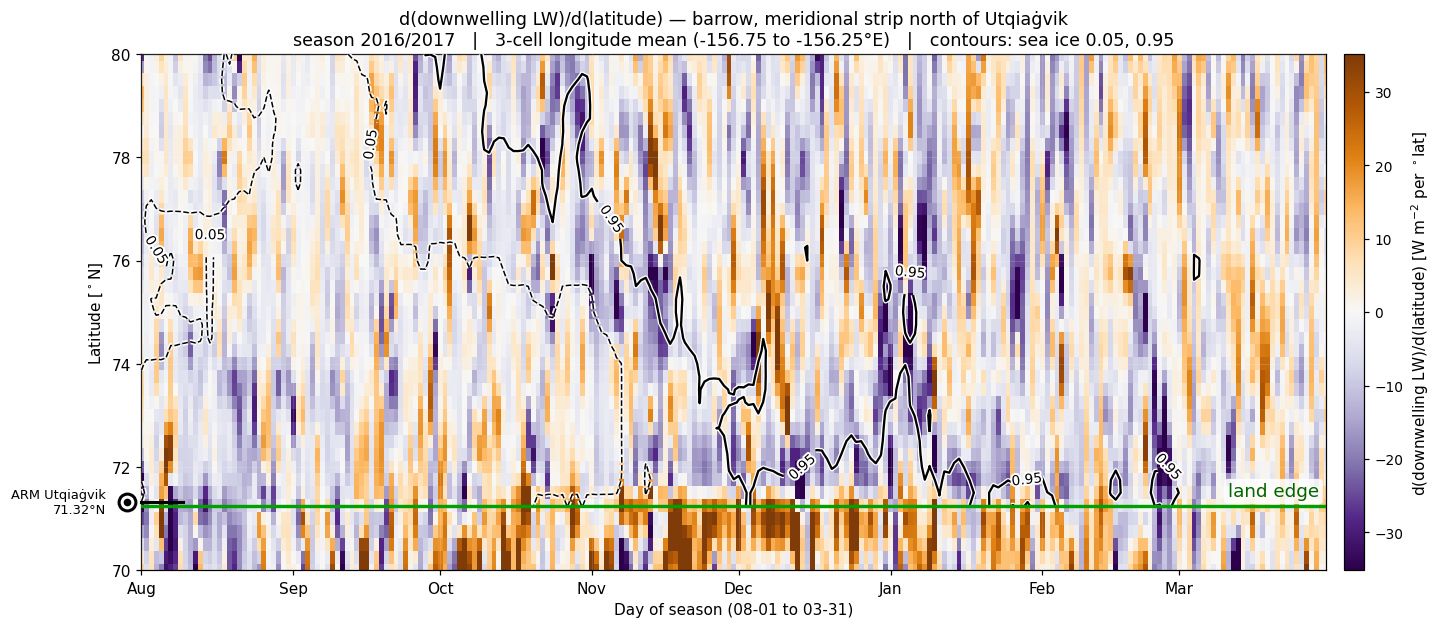

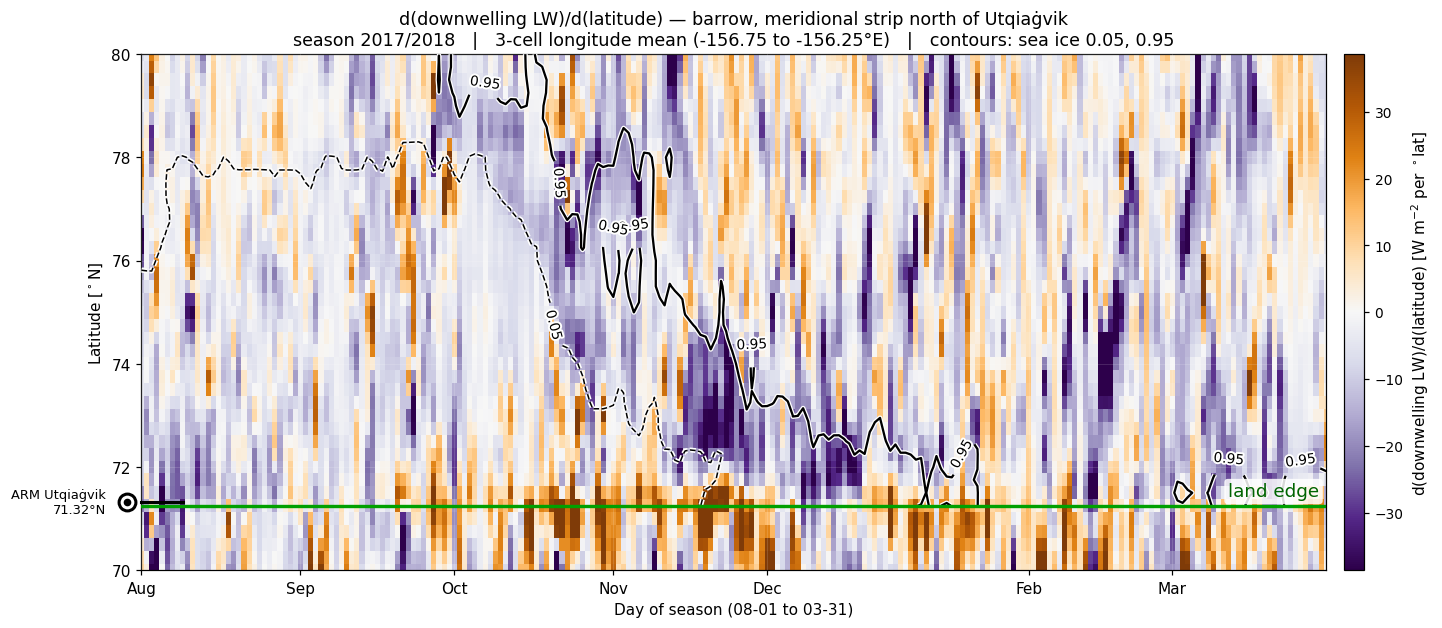

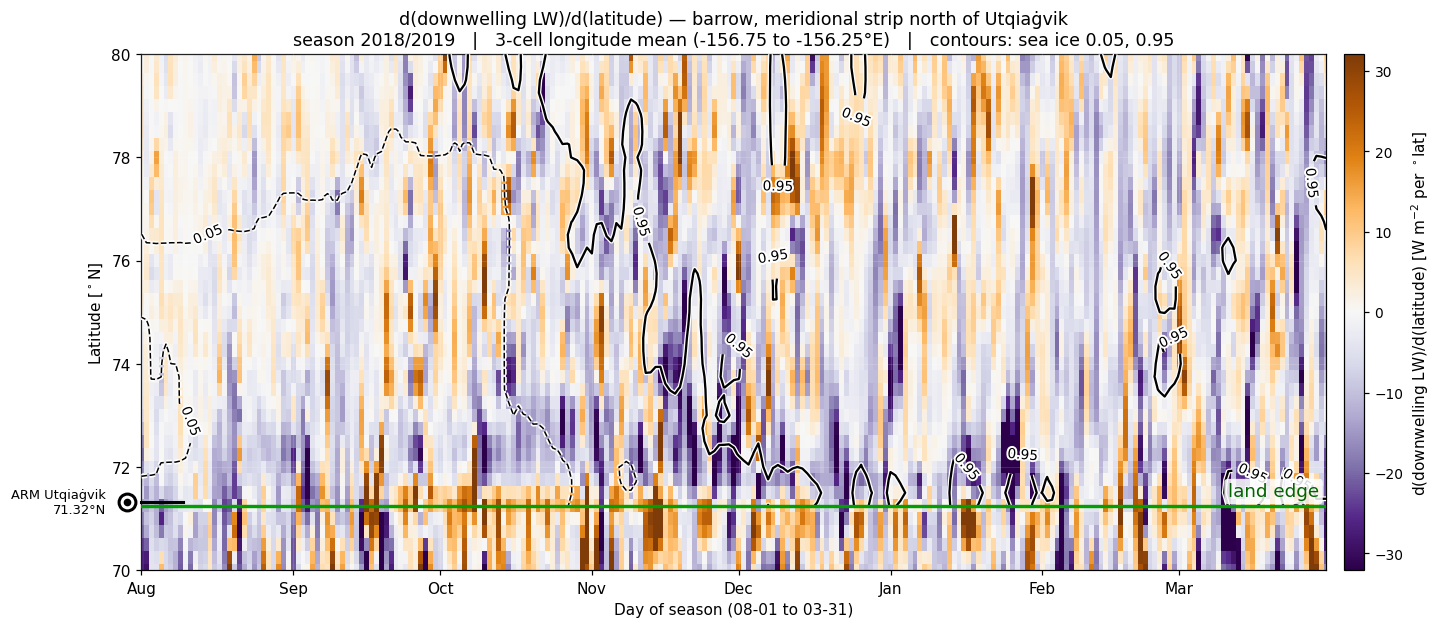

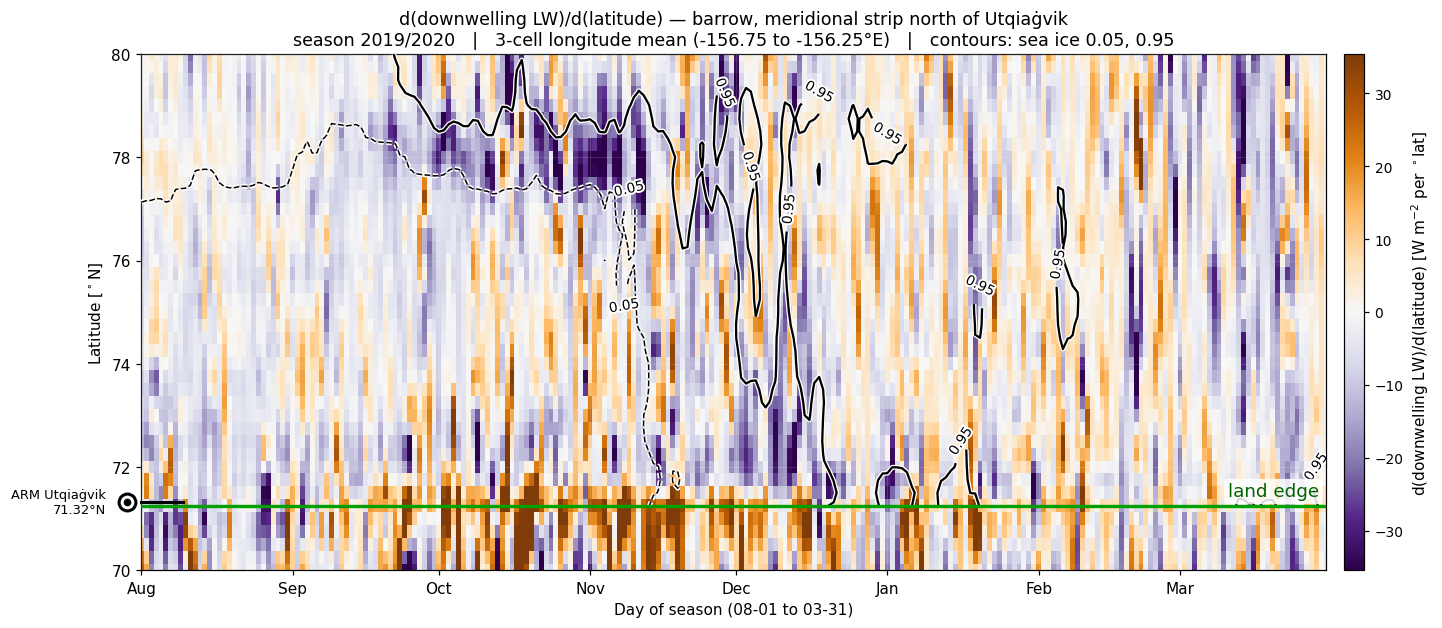

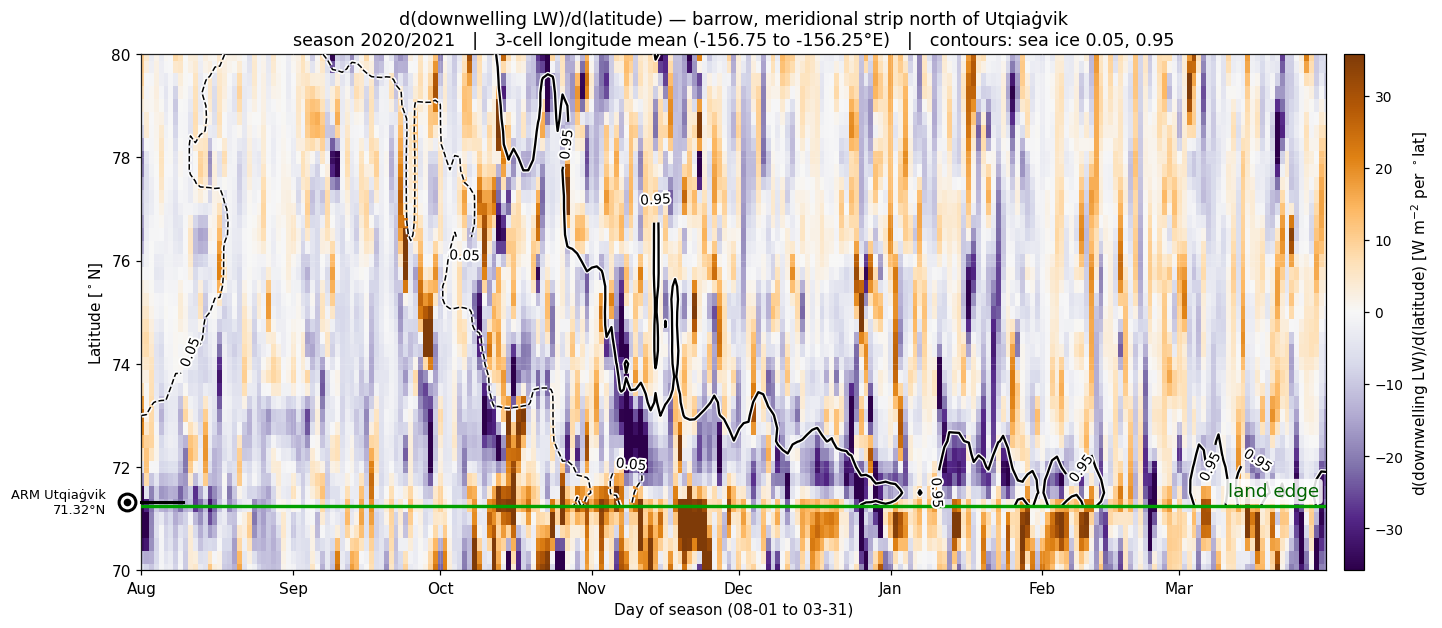

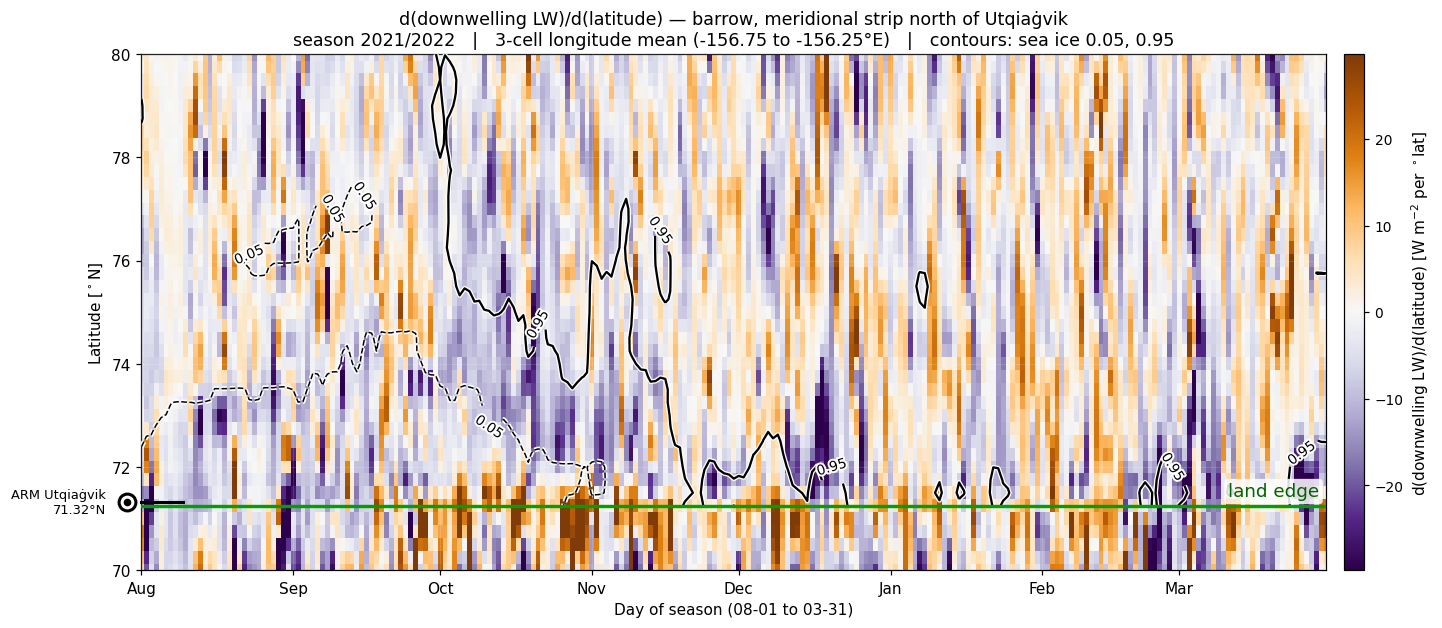

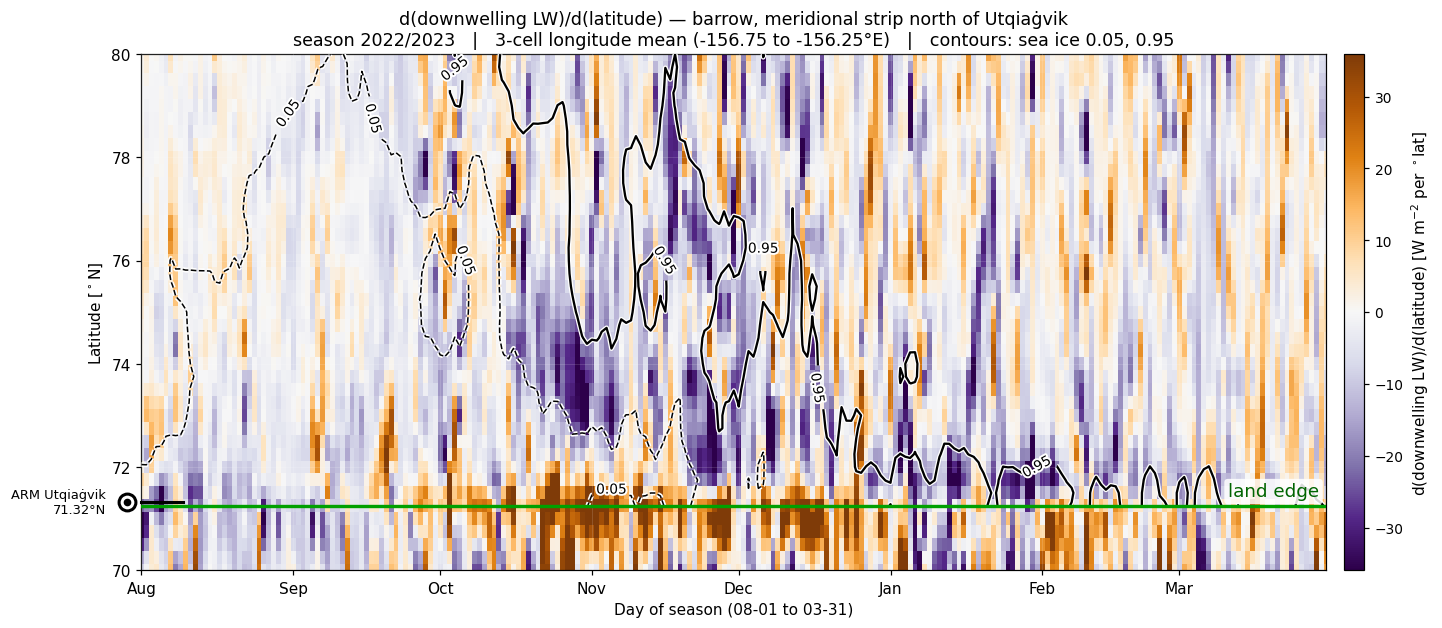

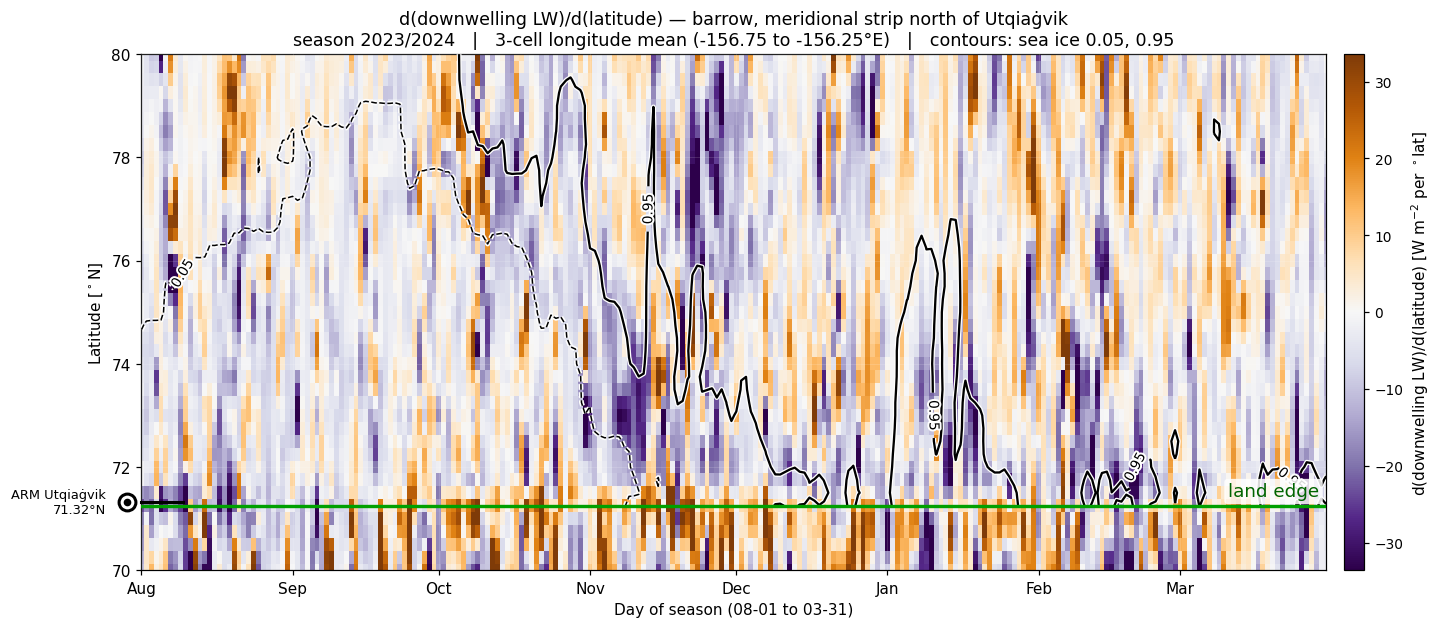

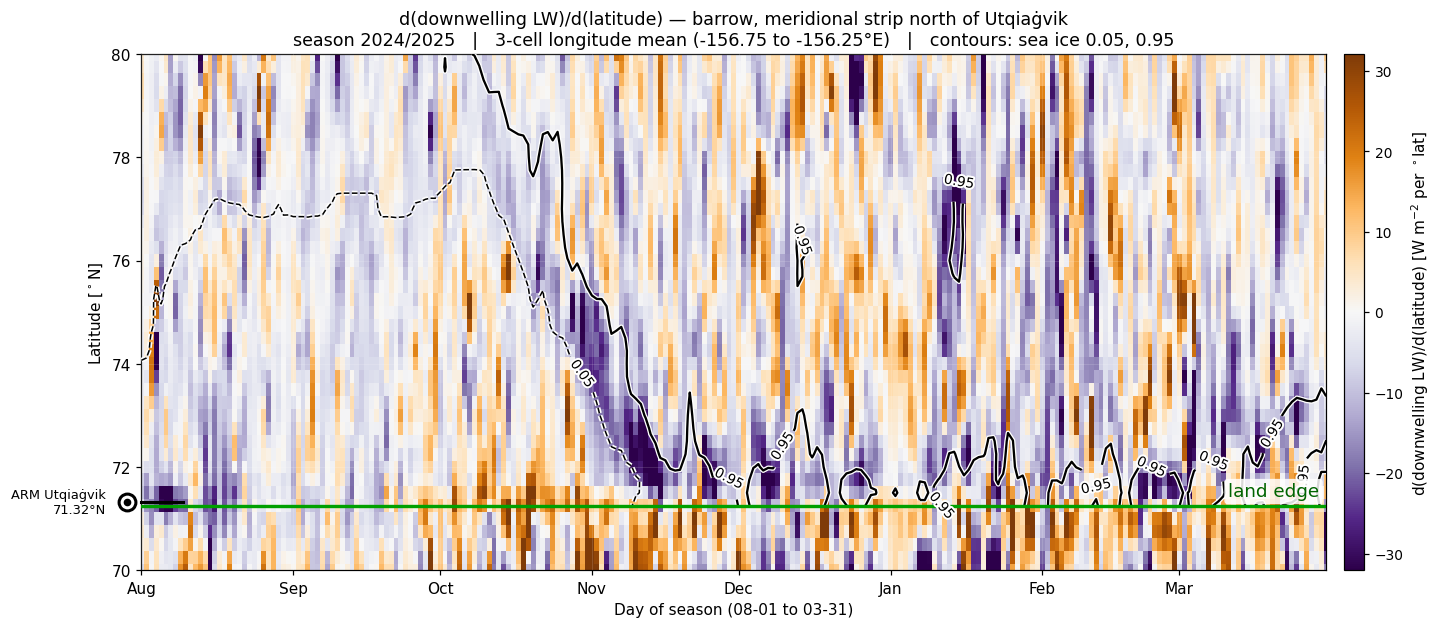

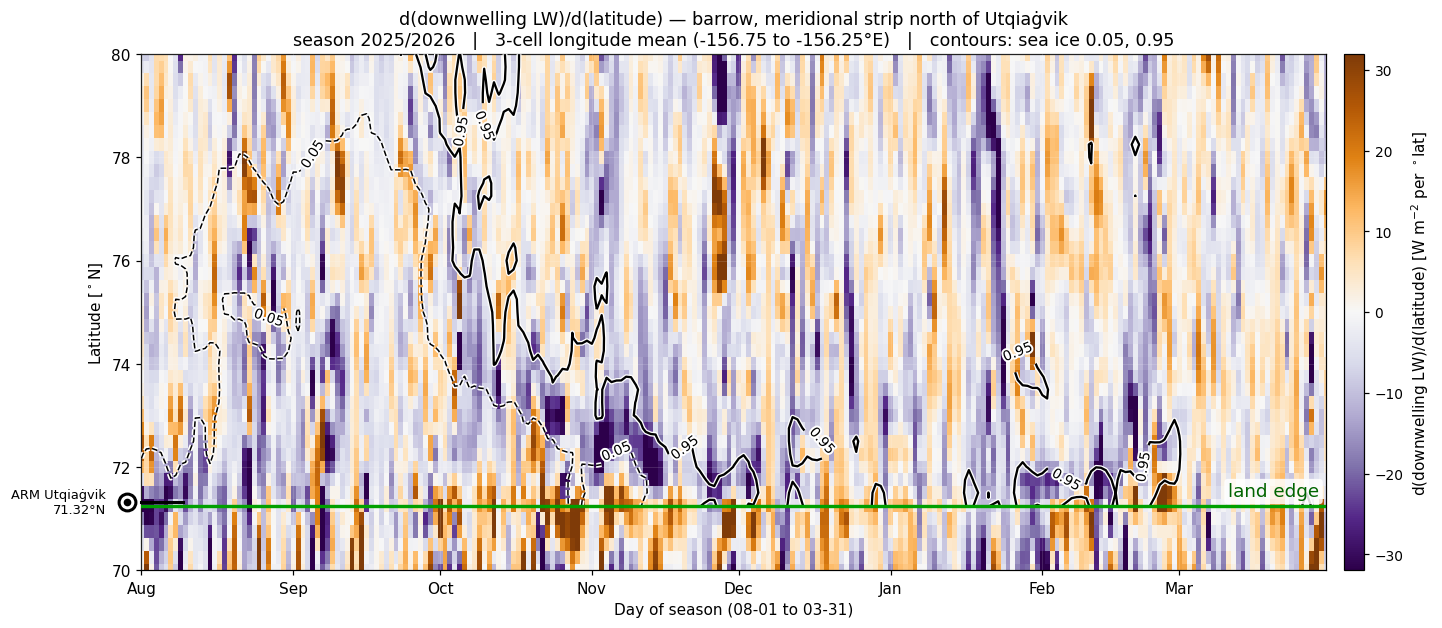

In [5]:
figs = hov.all_season_figures(A, out_dir=SAVE_DIR)
print(f"{len(figs)} figures")

## The climatology

All kept seasons averaged into one section — the same figure the command line
produces by default.

Worth reading against the per-season set above: seasons rarely cover the same
part of the window, so the number of contributing seasons varies along x, and
the script prints where it does. Vertical striping in the climatology usually
comes from that rather than from the atmosphere.


  Season coverage varies by day of season: 3-11 of 11 seasons contribute per column.
    29 Feb: only 3 season(s) wrap into a leap year and cover it -- expected, not a data gap.
    Other thin day(s): Jan 1 (10 of 11 seasons), Jan 2 (10 of 11 seasons), Jan 3 (10 of 11 seasons), Jan 4 (10 of 11 seasons), Jan 5 (10 of 11 seasons), Jan 6 (10 of 11 seasons), Jan 7 (10 of 11 seasons), Jan 8 (10 of 11 seasons), Jan 9 (10 of 11 seasons), Jan 10 (10 of 11 seasons), Jan 11 (10 of 11 seasons)
    figure -> figures/hovmoller_dlwd_dlat/barrow_hovmoller_dlwd_dlat_mean2015-2025.png


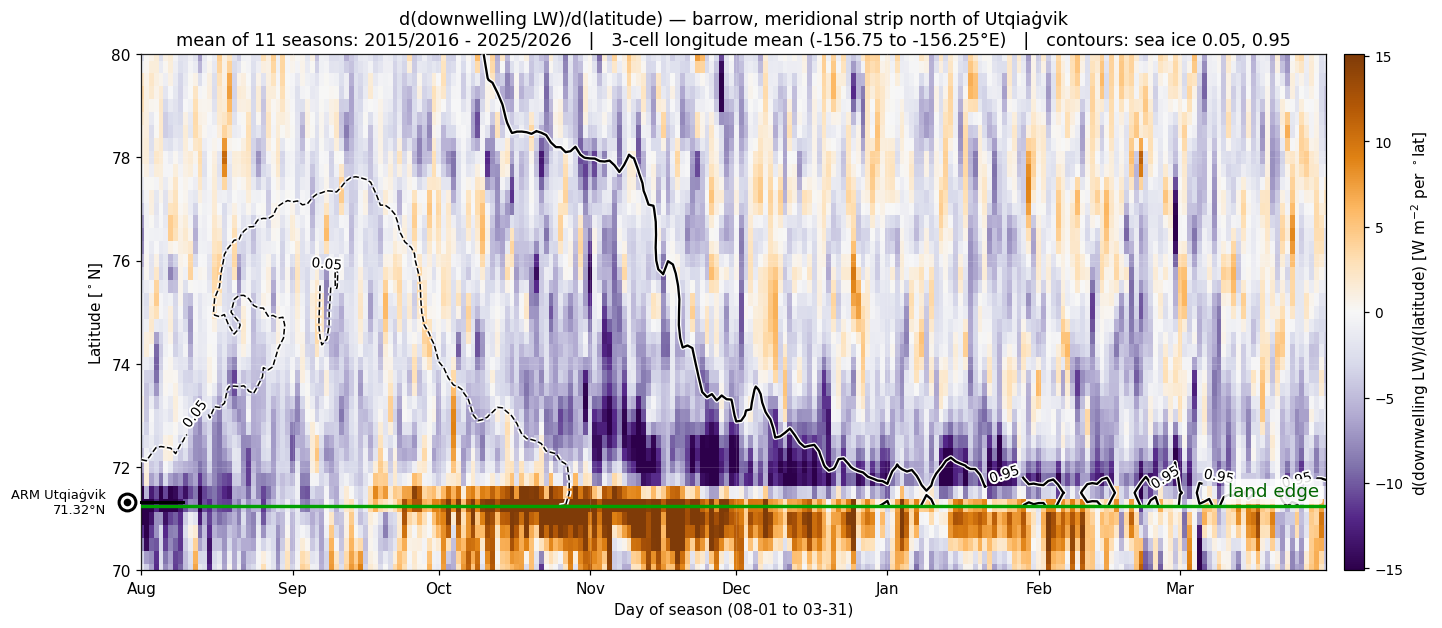

In [6]:
hov.mean_figure(A, out_dir=SAVE_DIR);

## One season on its own

`season_figure` takes the year the season starts in.

    figure -> figures/hovmoller_dlwd_dlat/barrow_hovmoller_dlwd_dlat_season2019.png


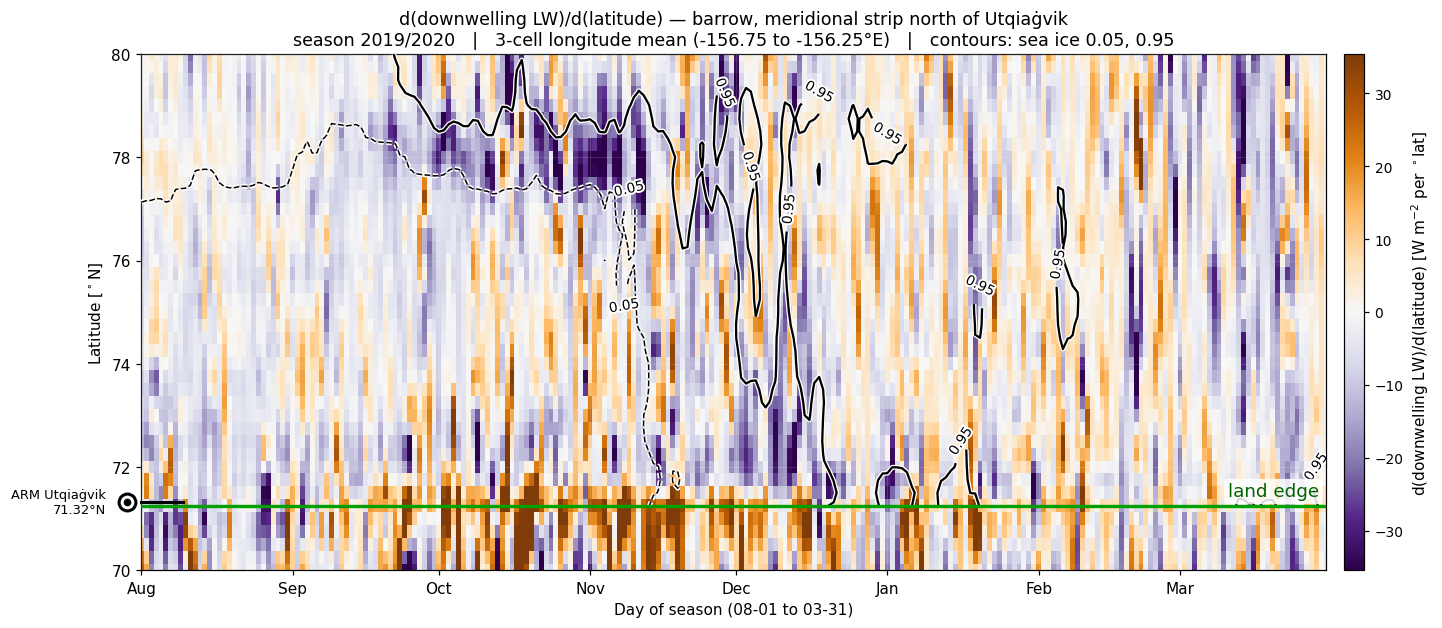

In [7]:
hov.season_figure(A, 2019, out_dir=SAVE_DIR);

## Changing options

Anything in the **Inputs** cell that alters what is loaded or sectioned —
region, years, season window, quantity, the strip geometry — needs a fresh
`prepare()`.

`ice_levels`, `contour_style` and `dpi` are read at **draw** time, so they can
be changed on the existing `A` without reloading:

```python
A.args.ice_levels = (0.15, 0.5, 0.9)
hov.mean_figure(A)
```

To get the other two quantities as well, section them all up front — one load,
three sets of figures:

```python
A_all = hov.prepare(region=REGION, years=YEARS, quantity="all",
                    season_start=SEASON_START, season_end=SEASON_END,
                    ice_levels=ICE_LEVELS)
hov.mean_figure(A_all, quantity="lwd")     # downwelling longwave
hov.mean_figure(A_all, quantity="lwnet")   # net longwave
hov.mean_figure(A_all, quantity="dlwd_dlat")
```

Asking a figure for a quantity `prepare()` did not section raises a `KeyError`
naming what it did build, rather than silently drawing the wrong field.